<a href="https://colab.research.google.com/github/kidanuadalia-oss/DS2022/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use GLMs and activation functions because real-world outcomes aren't always continuous and unbounded. If we're predicting a probability, a plain linear model can spit out values like 1.7 or -0.3, which make no sense. Activation functions like the sigmoid squish the output into a valid range (0 to 1 for probabilities). The advantage over linear models is that GLMs can handle different types of outcomes like binary, categorical, and count data, while still being interpretable.

2. Cross-entropy works well as a loss function because it directly measures how wrong the model's predicted probabilities are relative to the true labels. If the model is very confident and very wrong, the penalty is huge (log of a near-zero probability goes to negative infinity). If the model is confident and right, the loss is near zero. This asymmetry pushes the model to be calibrated and accurate, not just close. It also happens to be the negative log-likelihood of the Bernoulli distribution, so minimizing it is statistically principled.

3. True and false. Logistic regression is linear in the log-odds — the latent variable b⋅xb \cdot x
b⋅x is a linear combination of the features. But the predicted probability p^\hat{p}
p^​ is a nonlinear function of the features because of the sigmoid. So it's a generalized linear model — linear underneath, nonlinear in the output.

4. False. Logistic regression is actually one of the most common classification methods. You take the predicted probability and apply a threshold (usually 0.5) to get a hard class label. It's literally designed for this.

5. No. The coefficient doesn't tell you how much the predicted probability changes for a 1-unit change in xkx_k
xk​ — that marginal effect depends on where you are on the sigmoid curve (i.e., the current value of all your features). What the coefficient does tell you is how much the log odds change for a 1-unit increase in xkx_k
xk​, which is constant.

6. False. Even though logistic regression applies a nonlinear sigmoid, it still has a linear decision boundary in feature space. It can only separate classes linearly. So if the true relationship is curved or involves interactions, you still need feature engineering like polynomial terms and interactions.

7. False. Logistic regression and OLS are tools for different situations. OLS is appropriate for continuous outcomes and logistic regression is appropriate for binary or categorical ones. You shouldn't always prefer one over the other — it depends on what your outcome variable actually is.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [2]:
import urllib.request
import os
import zipfile

def download_data(force=False):
    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir

data_dir = download_data()
print(os.listdir(data_dir))

Download complete
Extracting data files...
Data extracted
['craiglist_cville_cars_long.csv', 'brazil_codebook.XLS', 'pierce_county_house_sales.csv', 'electricity_data_validation.csv', 'justice_data.parquet', 'patents.csv', 'sharks.csv', 'land_mines.csv', 'mnist', 'USA_cars_datasets.csv', 'weapons-trade-register.csv', 'cpr.txt', 'drilling_rigs.csv', 'Effectiveness of Bystander Cardiopulmonary Resuscitation and Survival Following Out-of-Hospital Cardiac Arrest.pdf', 'airbnb_NYC.csv', 'diabetes-dataset.csv', 'airbnb_hw.csv', 'college_completion.csv', 'crimebystatecombinedwithunemployment.csv', 'divorce', 'VirginiaPretrialData2017Codebook.pdf', 'brazil_default.csv', 'wages_hw.csv', 'energy.csv', 'heart_failure_readme.txt', '2022 election cycle fundraising.csv', 'metabric.csv', 'nhanes_data_17_18.csv', 'ForeignGifts_edu.csv', 'iowa.csv', 'ames_prices.csv', 'tuna.csv', 'heart_failure_clinical_records_dataset.csv', 'time_use.csv', 'CardiacPatientData.csv', 'use_of_force.txt', 'cars_hw.csv', '

In [3]:
for root, dirs, files in os.walk(data_dir):
    for file in files:
        print(os.path.join(root, file))

./data/craiglist_cville_cars_long.csv
./data/brazil_codebook.XLS
./data/pierce_county_house_sales.csv
./data/electricity_data_validation.csv
./data/justice_data.parquet
./data/patents.csv
./data/sharks.csv
./data/land_mines.csv
./data/USA_cars_datasets.csv
./data/weapons-trade-register.csv
./data/cpr.txt
./data/drilling_rigs.csv
./data/Effectiveness of Bystander Cardiopulmonary Resuscitation and Survival Following Out-of-Hospital Cardiac Arrest.pdf
./data/airbnb_NYC.csv
./data/diabetes-dataset.csv
./data/airbnb_hw.csv
./data/college_completion.csv
./data/crimebystatecombinedwithunemployment.csv
./data/VirginiaPretrialData2017Codebook.pdf
./data/brazil_default.csv
./data/wages_hw.csv
./data/energy.csv
./data/heart_failure_readme.txt
./data/2022 election cycle fundraising.csv
./data/metabric.csv
./data/nhanes_data_17_18.csv
./data/ForeignGifts_edu.csv
./data/iowa.csv
./data/ames_prices.csv
./data/tuna.csv
./data/heart_failure_clinical_records_dataset.csv
./data/time_use.csv
./data/Cardia

In [6]:
import pandas as pd
import io
import urllib.request
import zipfile

url = 'https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip'
urllib.request.urlretrieve(url, 'dropout.zip')

with zipfile.ZipFile('dropout.zip', 'r') as z:
    print(z.namelist())

['data.csv']


In [7]:
import pandas as pd
import zipfile

with zipfile.ZipFile('dropout.zip', 'r') as z:
    with z.open('data.csv') as f:
        dropout = pd.read_csv(f, sep=';')

print(dropout.head())
print(dropout.columns.tolist())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import zipfile

with zipfile.ZipFile('dropout.zip', 'r') as z:
    with z.open('data.csv') as f:
        df = pd.read_csv(f, sep=';')

cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols].copy()

print("Missing values:")
print(df.isnull().sum())
df = df.dropna()
print(f"\nShape after dropping missing values: {df.shape}")

df['dropout'] = (df['Target'] == 'Dropout').astype(int)
print("\nTarget distribution:")
print(df['Target'].value_counts())

Missing values:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Shape after dropping missing values: (4424, 6)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [23]:
features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features]
y = df['dropout']

log_model = LogisticRegression()
log_model.fit(X, y)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.coef_[0]
})
print(coef_df)

                   Feature  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


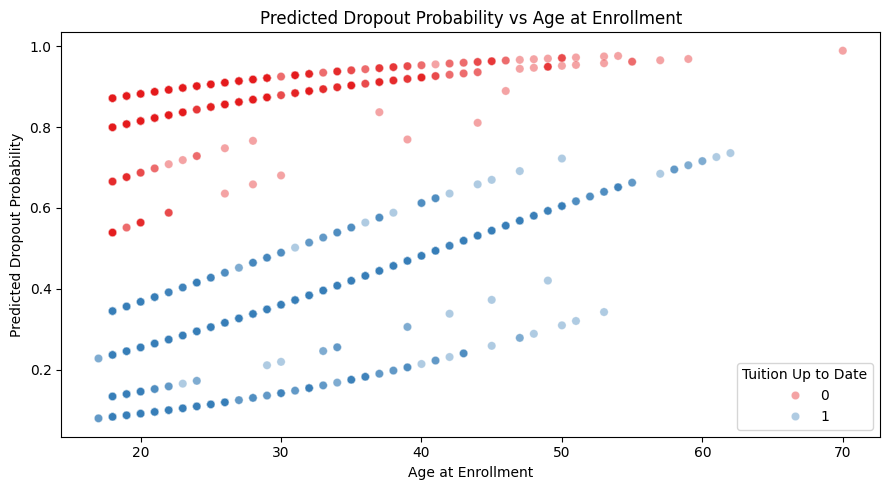

Tuition fees up to date
0    0.860675
1    0.248090
Name: predicted_prob, dtype: float64

Average difference in dropout probability: 0.6126


In [24]:
df['predicted_prob'] = log_model.predict_proba(X)[:, 1]

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Age at enrollment', y='predicted_prob',
                hue='Tuition fees up to date', alpha=0.4, palette='Set1')
plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.xlabel('Age at Enrollment')
plt.legend(title='Tuition Up to Date')
plt.tight_layout()
plt.show()

avg_by_tuition = df.groupby('Tuition fees up to date')['predicted_prob'].mean()
print(avg_by_tuition)
print(f"\nAverage difference in dropout probability: {avg_by_tuition[0] - avg_by_tuition[1]:.4f}")

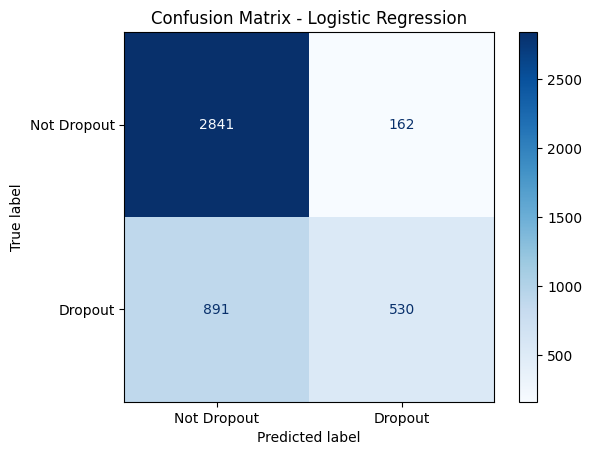

Accuracy: 0.7620


In [25]:
y_pred = log_model.predict(X)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Dropout', 'Dropout'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")

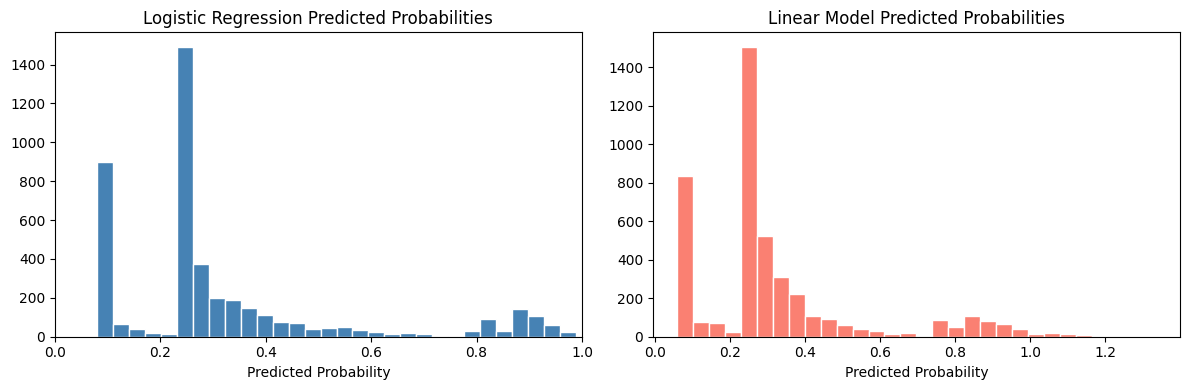

Linear model predictions out of [0,1] range: 57


In [26]:
lin_model = LinearRegression()
lin_model.fit(X, y)
df['linear_prob'] = lin_model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['predicted_prob'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression Predicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_xlim(0, 1)

axes[1].hist(df['linear_prob'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Linear Model Predicted Probabilities')
axes[1].set_xlabel('Predicted Probability')

plt.tight_layout()
plt.show()

out_of_range = ((df['linear_prob'] < 0) | (df['linear_prob'] > 1)).sum()
print(f"Linear model predictions out of [0,1] range: {out_of_range}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


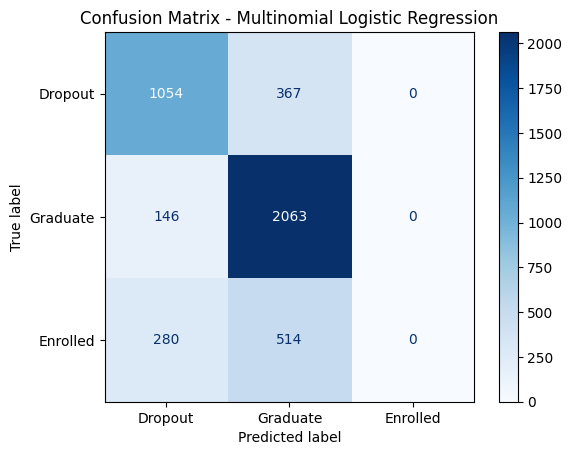

Hard classification unique predictions:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

Predicted probabilities (first 10 rows):
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104
5  0.308421  0.323433  0.368146
6  0.071938  0.140644  0.787418
7  0.952988  0.041199  0.005813
8  0.117808  0.176983  0.705209
9  0.838886  0.122977  0.038136


In [27]:
features_multi = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = df[features_multi]
y_multi = df['Target']

multi_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi_model.fit(X_multi, y_multi)

y_multi_pred = multi_model.predict(X_multi)

cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=['Dropout', 'Graduate', 'Enrolled'])
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=['Dropout', 'Graduate', 'Enrolled'])
disp_multi.plot(cmap='Blues')
plt.title('Confusion Matrix - Multinomial Logistic Regression')
plt.show()

print("Hard classification unique predictions:")
print(pd.Series(y_multi_pred).value_counts())

print("\nPredicted probabilities (first 10 rows):")
prob_df = pd.DataFrame(multi_model.predict_proba(X_multi), columns=multi_model.classes_)
print(prob_df.head(10))

2.2) Debtor (0.531) and Age at enrollment (0.050) predict higher dropout probability. Tuition fees up to date (-2.557) and Scholarship holder (-1.227) predict lower dropout probability. Yes, being up to date on tuition is by far the strongest predictor of lower dropout risk in the model.

2.3) Students not up to date on tuition have an average predicted dropout probability of 0.861 vs 0.248 for those who are up to date — a difference of about 0.613. The gap is most visible for students who enrolled between ages 18 and 30, where most of the data is concentrated.

2.4) The model achieves 76.2% accuracy. It does a reasonable job classifying both groups, though some accuracy is driven by the class imbalance favoring graduates and enrolled students.

2.5) The logistic regression keeps all predictions between 0 and 1. The linear model produces 57 predictions outside this range, making them invalid as probabilities. Logistic regression is clearly better suited for this binary classification task.

2.6) Students most at risk are debtors who are behind on tuition, have no scholarship, and enrolled older. Possible interventions include emergency financial aid, early alerts when tuition payments lapse, and dedicated advising for older students balancing outside responsibilities.

2.7) The hard classification only predicts Graduate and Dropout — it never predicts Enrolled. The predicted probabilities do assign values to all three classes, but Enrolled probabilities are always too low to win the hard classification. This is a common issue when one class is small and overlaps with the others.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [13]:
cirrhosis = pd.read_csv('https://archive.ics.uci.edu/static/public/878/data.csv')
print(cirrhosis.head())
print(cirrhosis.columns.tolist())
print(cirrhosis.shape)

   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin Cholesterol  Albumin Copper  Alk_Phos    SGOT  \
0     Y       14.5         261     2.60    156    1718.0  137.95   
1     N        1.1         302     4.14     54    7394.8  113.52   
2     S        1.4         176     3.48    210     516.0   96.10   
3     S        1.8         244     2.54     64    6121.8   60.63   
4     N        3.4         279     3.53    143     671.0  113.15   

  Tryglicerides Platelets  Prothrombin  Stage  
0           172       190         12.2    4.0  
1       

In [14]:
cirrhosis = pd.read_csv('https://archive.ics.uci.edu/static/public/878/data.csv')

cols = ['Status', 'Drug', 'Edema', 'Bilirubin', 'Stage']
circ = cirrhosis[cols].copy()

print("Missing values before dropping:")
print(circ.isnull().sum())

circ = circ.dropna()
print(f"\nShape after dropping missing values: {circ.shape}")

circ['alive'] = (circ['Status'] != 'D').astype(int)

print(circ['Status'].value_counts())
print(circ['alive'].value_counts())

Missing values before dropping:
Status         0
Drug         105
Edema          0
Bilirubin      0
Stage          6
dtype: int64

Shape after dropping missing values: (312, 5)
Status
C     168
D     125
CL     19
Name: count, dtype: int64
alive
1    187
0    125
Name: count, dtype: int64


In [17]:
from sklearn.preprocessing import LabelEncoder

circ_model = circ.copy()
circ_model['Edema'] = circ_model['Edema'].map({'N': 0, 'S': 1, 'Y': 2})
circ_model['Drug'] = circ_model['Drug'].map({'Placebo': 0, 'D-penicillamine': 1})

features_circ = ['Edema', 'Drug', 'Bilirubin']
X_circ = circ_model[features_circ]
y_circ = circ_model['alive']

circ_log = LogisticRegression()
circ_log.fit(X_circ, y_circ)

coef_circ = pd.DataFrame({
    'Feature': features_circ,
    'Coefficient': circ_log.coef_[0]
})
print(coef_circ)

     Feature  Coefficient
0      Edema    -0.915295
1       Drug    -0.223469
2  Bilirubin    -0.348584


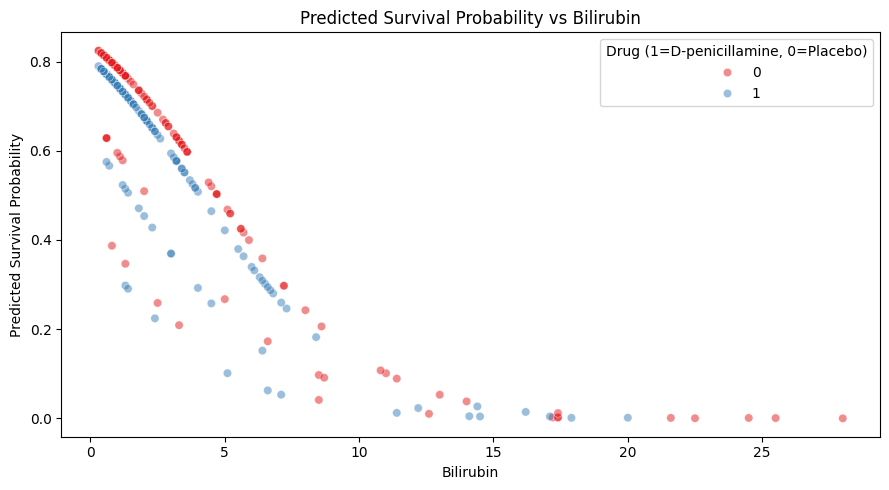

Drug
0    0.608928
1    0.590021
Name: predicted_prob, dtype: float64
Average difference in survival probability: -0.0189


In [18]:
circ_model['predicted_prob'] = circ_log.predict_proba(X_circ)[:, 1]

plt.figure(figsize=(9, 5))
sns.scatterplot(data=circ_model, x='Bilirubin', y='predicted_prob',
                hue='Drug', alpha=0.5, palette='Set1')
plt.title('Predicted Survival Probability vs Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.xlabel('Bilirubin')
plt.legend(title='Drug (1=D-penicillamine, 0=Placebo)')
plt.tight_layout()
plt.show()

avg_by_drug = circ_model.groupby('Drug')['predicted_prob'].mean()
print(avg_by_drug)
print(f"Average difference in survival probability: {avg_by_drug[1] - avg_by_drug[0]:.4f}")

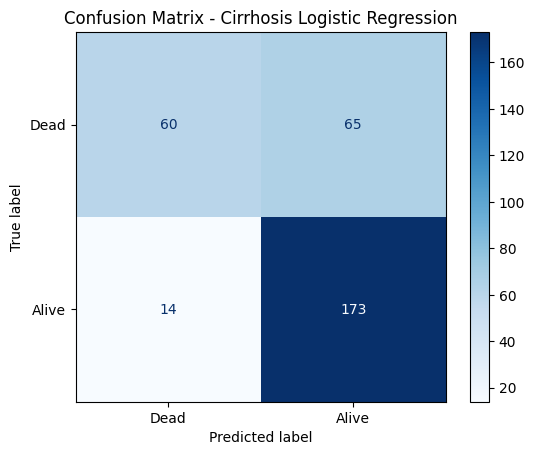

Accuracy: 0.7468


In [19]:
y_circ_pred = circ_log.predict(X_circ)

cm_circ = confusion_matrix(y_circ, y_circ_pred)
disp_circ = ConfusionMatrixDisplay(confusion_matrix=cm_circ, display_labels=['Dead', 'Alive'])
disp_circ.plot(cmap='Blues')
plt.title('Confusion Matrix - Cirrhosis Logistic Regression')
plt.show()

print(f"Accuracy: {accuracy_score(y_circ, y_circ_pred):.4f}")

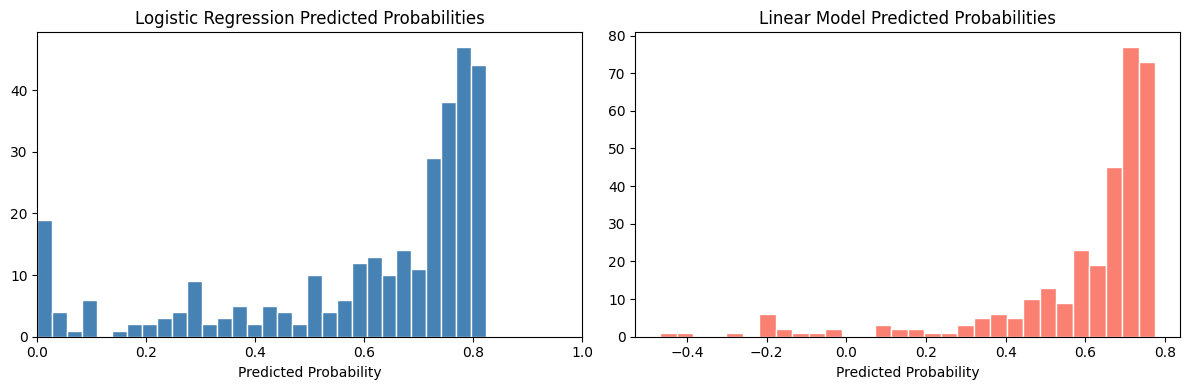

Linear model predictions out of [0,1] range: 15


In [20]:
lin_circ = LinearRegression()
lin_circ.fit(X_circ, y_circ)
circ_model['linear_prob'] = lin_circ.predict(X_circ)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(circ_model['predicted_prob'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression Predicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_xlim(0, 1)

axes[1].hist(circ_model['linear_prob'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Linear Model Predicted Probabilities')
axes[1].set_xlabel('Predicted Probability')

plt.tight_layout()
plt.show()

print(f"Linear model predictions out of [0,1] range: {((circ_model['linear_prob'] < 0) | (circ_model['linear_prob'] > 1)).sum()}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


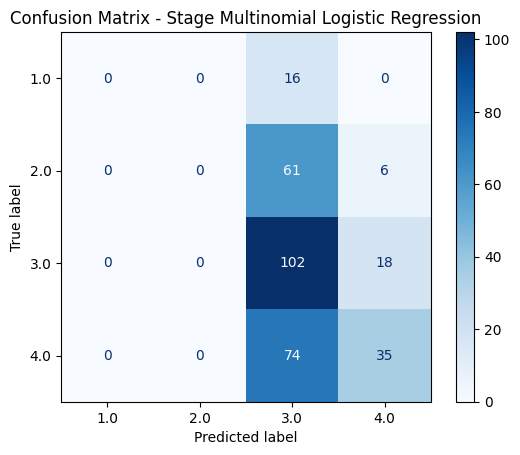

Hard classification unique predictions:
3.0    253
4.0     59
Name: count, dtype: int64

Predicted probabilities (first 10 rows):
        1.0       2.0       3.0       4.0
0  0.000004  0.026212  0.163753  0.810031
1  0.073533  0.252875  0.400994  0.272598
2  0.026874  0.172054  0.337700  0.463372
3  0.021408  0.167391  0.338390  0.472811
4  0.020987  0.227850  0.428140  0.323023
5  0.085983  0.254517  0.394762  0.264738
6  0.077488  0.253485  0.399007  0.270020
7  0.110972  0.255845  0.382449  0.250734
8  0.023467  0.230540  0.426849  0.319144
9  0.000012  0.032180  0.174739  0.793069


In [21]:
features_stage = ['Edema', 'Bilirubin']
X_stage = circ_model[features_stage]
y_stage = circ_model['Stage']

stage_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
stage_model.fit(X_stage, y_stage)

y_stage_pred = stage_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_stage_pred)
disp_stage = ConfusionMatrixDisplay(confusion_matrix=cm_stage, display_labels=stage_model.classes_)
disp_stage.plot(cmap='Blues')
plt.title('Confusion Matrix - Stage Multinomial Logistic Regression')
plt.show()

print("Hard classification unique predictions:")
print(pd.Series(y_stage_pred).value_counts())

print("\nPredicted probabilities (first 10 rows):")
stage_prob_df = pd.DataFrame(stage_model.predict_proba(X_stage), columns=stage_model.classes_)
print(stage_prob_df.head(10))

3.1) Drug had 105 missing values and Stage had 6. All rows with missing values were dropped, leaving 312 observations. Status was recoded as 1 for alive (C or CL) and 0 for dead (D).

3.2) All three coefficients are negative — Edema (-0.915), Drug (-0.223), and Bilirubin (-0.349) — meaning higher values of each are associated with lower survival probability. The drug does not appear to improve survival. Higher bilirubin predicts worse outcomes, which makes clinical sense for liver disease.

3.3) Placebo patients average 0.609 predicted survival probability vs 0.590 for drug patients — about a 1.9 percentage point difference. The drug shows no meaningful benefit at any level of bilirubin based on the scatter plot.

3.4) The model achieves 74.7% accuracy. It identifies survivors reasonably well but struggles more with deceased patients due to class imbalance.

3.5) The logistic regression keeps all predictions in [0,1]. The linear model produces 15 out-of-range predictions. Logistic regression is the better choice for predicting probabilities here.

3.6) The hard classification only predicts stages 3 and 4, never stages 1 or 2. The predicted probabilities do cover all four stages but stage 1 and 2 probabilities are so small they never win the hard classification. This shows a key limitation of multinomial logistic regression on imbalanced ordinal data.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

For a linear model, the prediction is:

$$\hat{y} = b_0 + \sum_{k=1}^K b_k x_k$$

Taking the derivative with respect to the $k$-th feature:

$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

The derivative is just $b_k$ and it is constant no matter what. For a 1-unit change in $x_k$, the prediction changes by exactly $b_k$, regardless of the values of any other features.

Let $L = b \cdot x$, so $\hat{p} = \frac{e^L}{1+e^L}$. Using the chain rule:

$$\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial \hat{p}}{\partial L} \cdot \frac{\partial L}{\partial x_k} = \hat{p}(1 - \hat{p}) \cdot b_k$$

Unlike the linear model, this is not constant. It depends on $\hat{p}$, which changes with every observation depending on all the feature values. As $x$ changes, so does $\hat{p}$, and so does the marginal effect.

The term $\hat{p}(1-\hat{p})$ is maximized when $\hat{p} = 0.5$, where it equals $0.25$. So when $\hat{p} \approx 0.5$:

$$\frac{\partial \hat{p}}{\partial x_k} \approx \frac{b_k}{4}$$

This means $b_k$ times $\frac{1}{4}$ is a decent approximation of the marginal effect when the predicted probability is near 0.5. Out near the tails where $\hat{p}$ is close to 0 or 1, $\hat{p}(1-\hat{p})$ shrinks toward zero and a 1-unit change in $x_k$ barely shifts the predicted probability at all.

From the derivation in the problem:

$$\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x$$

Taking the derivative with respect to $x_k$:

$$\frac{\partial}{\partial x_k}\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k$$

A 1-unit increase in $x_k$ increases the log odds ratio by exactly $b_k$, and this is constant regardless of the values of any other features. This is the cleanest way to interpret logistic regression coefficients. If you exponentiate, $e^{b_k}$ gives the odds ratio, which is the multiplicative change in the odds of the outcome for a 1-unit increase in $x_k$.